In [1]:
# ============================================================
# CELL 1 — ENVIRONMENT CHECK
# ============================================================

import torch
import platform
import os

print("Python version:", platform.python_version())
print("Torch version:", torch.__version__)

print("\nCUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory (GB):", round(torch.cuda.get_device_properties(0).total_memory/1e9,2))

print("\nWorking directory:", os.getcwd())

Python version: 3.12.12
Torch version: 2.9.0+cu126

CUDA available: True
GPU: Tesla P100-PCIE-16GB
GPU memory (GB): 17.06

Working directory: /kaggle/working


In [2]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import cv2

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms

from sklearn.metrics import accuracy_score, f1_score, classification_report

import librosa

print("All libraries imported successfully.") 

All libraries imported successfully.


In [3]:
# ============================================================
# CELL 3 — DATASET PATHS
# ============================================================

from pathlib import Path

# Root dataset directory
DATA_ROOT = Path("/kaggle/input/datasets/ajfaisal002/crossmodal-misleading-video-dataset")

# Frames
TRAIN_FRAMES = DATA_ROOT / "dataset_kaggle/extracted_frames/train"
TEST_FRAMES  = DATA_ROOT / "dataset_kaggle/extracted_frames/test"

# Audio
TRAIN_AUDIO = DATA_ROOT / "extracted_audio/extracted_audio/train"
TEST_AUDIO  = DATA_ROOT / "extracted_audio/extracted_audio/test"

# Metadata CSV
TRAIN_META = DATA_ROOT / "dataset_kaggle/extracted_text/train_metadata.csv"
TEST_META  = DATA_ROOT / "dataset_kaggle/extracted_text/test_metadata.csv"

print("Dataset paths loaded\n")

print("TRAIN_FRAMES:", TRAIN_FRAMES)
print("TEST_FRAMES :", TEST_FRAMES)

print("\nTRAIN_AUDIO:", TRAIN_AUDIO)
print("TEST_AUDIO :", TEST_AUDIO)

print("\nTRAIN_META:", TRAIN_META)
print("TEST_META :", TEST_META)

Dataset paths loaded

TRAIN_FRAMES: /kaggle/input/datasets/ajfaisal002/crossmodal-misleading-video-dataset/dataset_kaggle/extracted_frames/train
TEST_FRAMES : /kaggle/input/datasets/ajfaisal002/crossmodal-misleading-video-dataset/dataset_kaggle/extracted_frames/test

TRAIN_AUDIO: /kaggle/input/datasets/ajfaisal002/crossmodal-misleading-video-dataset/extracted_audio/extracted_audio/train
TEST_AUDIO : /kaggle/input/datasets/ajfaisal002/crossmodal-misleading-video-dataset/extracted_audio/extracted_audio/test

TRAIN_META: /kaggle/input/datasets/ajfaisal002/crossmodal-misleading-video-dataset/dataset_kaggle/extracted_text/train_metadata.csv
TEST_META : /kaggle/input/datasets/ajfaisal002/crossmodal-misleading-video-dataset/dataset_kaggle/extracted_text/test_metadata.csv


In [4]:
# ============================================================
# CELL 4 — DATASET INTEGRITY CHECK
# ============================================================

import pandas as pd

# Load metadata
train_df = pd.read_csv(TRAIN_META)
test_df  = pd.read_csv(TEST_META)

print("Train samples:", len(train_df))
print("Test samples :", len(test_df))

print("\nColumns:")
print(train_df.columns)

print("\nFirst 5 rows:")
display(train_df.head())

print("\nClass distribution (train):")
print(train_df["subcategory"].value_counts())

Train samples: 1600
Test samples : 800

Columns:
Index(['video_id', 'has_audio', 'transcript', 'ocr_text', 'category',
       'subcategory'],
      dtype='object')

First 5 rows:


,video_id,has_audio,transcript,ocr_text,category,subcategory
0,IF_001,True,আপনি সিদ্ধান্ত নিয়েছেন একটি নতুন অ্যাপ্লিকেশন...,OR EVEN TAKA ON YOUR FIRST CRAZY TIME,misleading,identity_fabrication
1,IF_002,True,"With a small investment of 30,500 Bangladeshi ...",YES WITH A SMALL INVESTMENT OF BANGLADESH TAKA...,misleading,identity_fabrication
2,IF_003,True,"If they close this page, they can't come back ...",IF THEY CLOSE THIS PAGE AS WILL THEIR CHANCE T...,misleading,identity_fabrication
3,IF_004,True,We tested our product with a small group of vo...,AND EACH OF THEM EARNED OVER BANGLADESHI TAKA ...,misleading,identity_fabrication
4,IF_005,True,I am ready to give you your money back from my...,MONEY BACK FROM MY POCKET BANGLADESHI TAKA,misleading,identity_fabrication



Class distribution (train):
subcategory
identity_fabrication                200
perception_manipulation             200
scientifically_unrealistic_scene    200
surreal_content                     200
Name: count, dtype: int64


In [5]:
# ============================================================
# CELL 5 — LABEL MAPPING
# ============================================================

# Full 5-class mapping
label_map = {
    "safe": 0,
    "identity_fabrication": 1,
    "perception_manipulation": 2,
    "scientifically_unrealistic_scene": 3,
    "surreal_content": 4
}

# Binary mapping (Stage-1)
binary_map = {
    "safe": 0,
    "misleading": 1
}

# Misleading mapping (Stage-2)
misleading_map = {
    "identity_fabrication": 0,
    "perception_manipulation": 1,
    "scientifically_unrealistic_scene": 2,
    "surreal_content": 3
}

print("5-class map:", label_map)
print("Binary map:", binary_map)
print("Misleading map:", misleading_map)

5-class map: {'safe': 0, 'identity_fabrication': 1, 'perception_manipulation': 2, 'scientifically_unrealistic_scene': 3, 'surreal_content': 4}
Binary map: {'safe': 0, 'misleading': 1}
Misleading map: {'identity_fabrication': 0, 'perception_manipulation': 1, 'scientifically_unrealistic_scene': 2, 'surreal_content': 3}


In [6]:
# ============================================================
# CELL 6 — AUDIO MFCC EXTRACTION
# ============================================================

import librosa
import numpy as np

def extract_mfcc(audio_path, max_len=160, n_mfcc=40):
    
    try:
        # load audio
        y, sr = librosa.load(audio_path, sr=16000)

        # compute MFCC
        mfcc = librosa.feature.mfcc(
            y=y,
            sr=sr,
            n_mfcc=n_mfcc
        )

        # truncate or pad time dimension
        if mfcc.shape[1] > max_len:
            mfcc = mfcc[:, :max_len]
        else:
            pad_width = max_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, ((0,0),(0,pad_width)), mode="constant")

    except Exception as e:
        # fallback if audio missing or corrupted
        mfcc = np.zeros((n_mfcc, max_len))

    return mfcc.astype(np.float32)


print("MFCC extractor ready")

MFCC extractor ready


In [7]:
# ============================================================
# CELL 7 — TEST MFCC EXTRACTION
# ============================================================

import random

# pick a random audio file
audio_files = list(TRAIN_AUDIO.glob("*.wav"))

print("Total audio files:", len(audio_files))

sample_audio = random.choice(audio_files)

print("Sample audio:", sample_audio)

mfcc = extract_mfcc(sample_audio)

print("MFCC shape:", mfcc.shape)
print("MFCC min:", mfcc.min())
print("MFCC max:", mfcc.max())

Total audio files: 1600
Sample audio: /kaggle/input/datasets/ajfaisal002/crossmodal-misleading-video-dataset/extracted_audio/extracted_audio/train/SAFE_122.wav
MFCC shape: (40, 160)
MFCC min: -401.42136
MFCC max: 174.20972


In [8]:
# ============================================================
# CELL 7 — TEST MFCC EXTRACTION (FULL CHECK)
# ============================================================

import random

audio_files = list(TRAIN_AUDIO.glob("*.wav"))

print("Total audio files:", len(audio_files))

sample_audio = random.choice(audio_files)

print("Sample audio:", sample_audio)

mfcc = extract_mfcc(sample_audio)

print("\nMFCC shape:", mfcc.shape)
print("MFCC dtype:", mfcc.dtype)

print("MFCC min:", np.min(mfcc))
print("MFCC max:", np.max(mfcc))

print("\nAny NaN:", np.isnan(mfcc).any())

Total audio files: 1600
Sample audio: /kaggle/input/datasets/ajfaisal002/crossmodal-misleading-video-dataset/extracted_audio/extracted_audio/train/IF_174.wav

MFCC shape: (40, 160)
MFCC dtype: float32
MFCC min: -520.8354
MFCC max: 192.94998

Any NaN: False


In [9]:
# ============================================================
# CELL 8 — FRAME LOADER
# ============================================================

import cv2
import torch
import torchvision.transforms as transforms

# CLIP image preprocessing
frame_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.48145466, 0.4578275, 0.40821073],
        std=[0.26862954, 0.26130258, 0.27577711]
    )
])

def load_frames(video_id, frames_root, num_frames=16):

    video_dir = frames_root / video_id

    frame_files = sorted(video_dir.glob("*.jpg"))

    frames = []

    for i in range(num_frames):

        if i < len(frame_files):
            img = cv2.imread(str(frame_files[i]))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            img = np.zeros((224,224,3), dtype=np.uint8)

        img = frame_transform(img)

        frames.append(img)

    frames = torch.stack(frames)

    return frames


print("Frame loader ready")

Frame loader ready


In [10]:
# ============================================================
# CELL 9 — TEST FRAME LOADING
# ============================================================

import random

# get random video folder
video_dirs = list(TRAIN_FRAMES.glob("*"))

print("Total train videos:", len(video_dirs))

sample_video = random.choice(video_dirs)

print("Sample video:", sample_video.name)

frames = load_frames(sample_video.name, TRAIN_FRAMES)

print("\nFrames tensor shape:", frames.shape)
print("Tensor dtype:", frames.dtype)
print("Min value:", frames.min().item())
print("Max value:", frames.max().item())

Total train videos: 1600
Sample video: SAFE_532

Frames tensor shape: torch.Size([16, 3, 224, 224])
Tensor dtype: torch.float32
Min value: -1.7922625541687012
Max value: 2.1458969116210938


In [11]:
# ============================================================
# CELL 10 — MULTIMODAL DATASET
# ============================================================

class MultimodalDataset(Dataset):
    
    def __init__(self, dataframe, frames_root, audio_root):
        
        self.df = dataframe.reset_index(drop=True)
        self.frames_root = frames_root
        self.audio_root = audio_root
        
    def __len__(self):
        return len(self.df)
    
    
    def get_label(self, row):
        
        # safe videos
        if row["category"] == "safe":
            return label_map["safe"]
        
        # misleading videos
        return label_map[row["subcategory"]]
    
    
    def __getitem__(self, idx):
        
        row = self.df.iloc[idx]
        
        video_id = row["video_id"]
        
        # -----------------------
        # Vision
        # -----------------------
        frames = load_frames(video_id, self.frames_root)
        
        
        # -----------------------
        # Text
        # -----------------------
        transcript = str(row["transcript"])
        ocr = str(row["ocr_text"])
        
        text = transcript + " " + ocr
        
        
        # -----------------------
        # Audio
        # -----------------------
        audio_path = self.audio_root / f"{video_id}.wav"
        
        mfcc = extract_mfcc(audio_path)
        
        audio = torch.tensor(mfcc).unsqueeze(0)
        
        
        # -----------------------
        # Label
        # -----------------------
        label = self.get_label(row)
        
        
        return {
            "frames": frames,
            "text": text,
            "audio": audio,
            "label": label
        }


print("MultimodalDataset class created.")

MultimodalDataset class created.


In [12]:
# ============================================================
# CELL 11 — TEST DATASET
# ============================================================

train_dataset = MultimodalDataset(
    train_df,
    TRAIN_FRAMES,
    TRAIN_AUDIO
)

print("Dataset size:", len(train_dataset))

sample = train_dataset[29]

print("\nKeys:", sample.keys())

print("\nFrames shape:", sample["frames"].shape)
print("Audio shape:", sample["audio"].shape)

print("\nLabel:", sample["label"])

print("\nText preview:")
print(sample["text"][:200])

Dataset size: 1600

Keys: dict_keys(['frames', 'text', 'audio', 'label'])

Frames shape: torch.Size([16, 3, 224, 224])
Audio shape: torch.Size([1, 40, 160])

Label: 1

Text preview:
Hey Chino man, you brought the National Guard to a chancla fight. YOU BROUGHT THE NATIONAL GUARD TO A CHURCH FIGHT YOU BROUGHT THE NATIONAL GUARD TO A CHICKEN FIGHT


In [13]:
# ============================================================
# CELL 12 — DATALOADER
# ============================================================

BATCH_SIZE = 4

train_dataset = MultimodalDataset(
    train_df,
    TRAIN_FRAMES,
    TRAIN_AUDIO
)

test_dataset = MultimodalDataset(
    test_df,
    TEST_FRAMES,
    TEST_AUDIO
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 400
Test batches: 200


In [14]:
# ============================================================
# CELL 13 — LOAD ENCODERS
# ============================================================

from transformers import CLIPModel, AutoTokenizer, AutoModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CLIP (Vision)
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)

# Text encoder
tokenizer = AutoTokenizer.from_pretrained("roberta-base")
text_model = AutoModel.from_pretrained("roberta-base").to(device)

# Freeze encoders to save memory
for p in clip_model.parameters():
    p.requires_grad = False

for p in text_model.parameters():
    p.requires_grad = False

clip_model.eval()
text_model.eval()

print("Encoders loaded and frozen.")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Encoders loaded and frozen.


In [15]:
# ============================================================
# CELL 14 — SAFE EMBEDDING FUNCTIONS
# ============================================================

def clip_vision_embed(pixel_values):
    """
    Safe CLIP vision embedding.
    Always returns a tensor of shape (B, 768)
    """

    outputs = clip_model.vision_model(pixel_values=pixel_values)

    if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
        return outputs.pooler_output

    return outputs.last_hidden_state.mean(dim=1)


def text_embed(text_list):
    """
    Text embedding using RoBERTa
    Returns tensor (B, 768)
    """

    tokens = tokenizer(
        text_list,
        padding=True,
        truncation=True,
        max_length=77,
        return_tensors="pt"
    ).to(device)

    outputs = text_model(**tokens)

    return outputs.last_hidden_state[:,0,:]


print("Safe embedding functions ready.")

Safe embedding functions ready.


In [16]:
# ============================================================
# CELL 15 — DETECT FEATURE DIMENSIONS
# ============================================================

batch = next(iter(train_loader))

frames = batch["frames"]
texts = batch["text"]
audio = batch["audio"]

B = frames.size(0)

# -------------------------
# Vision features
# -------------------------
frames = frames.view(-1,3,224,224).to(device)

with torch.no_grad():
    vision_feat = clip_vision_embed(frames)

vision_feat = vision_feat.view(B,16,-1).mean(dim=1)

# -------------------------
# Text features
# -------------------------
with torch.no_grad():
    text_feat = text_embed(list(texts))

# -------------------------
# Audio dimension (MFCC)
# -------------------------
audio_feat = audio.view(B,-1)

vision_dim = vision_feat.shape[1]
text_dim = text_feat.shape[1]
audio_dim = audio_feat.shape[1]

fusion_dim = vision_dim + text_dim + audio_dim

print("Vision dim:", vision_dim)
print("Text dim:", text_dim)
print("Audio dim:", audio_dim)
print("Fusion dim:", fusion_dim)

Vision dim: 768
Text dim: 768
Audio dim: 6400
Fusion dim: 7936


In [17]:
# ============================================================
# CELL 16 — AUDIO CNN ENCODER
# ============================================================

class AudioEncoder(nn.Module):
    
    def __init__(self, out_dim=128):
        super().__init__()
        
        self.net = nn.Sequential(
            
            nn.Conv2d(1,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4))
        )
        
        self.fc = nn.Linear(64*4*4,out_dim)
    
    
    def forward(self,x):
        
        x = self.net(x)
        
        x = x.view(x.size(0),-1)
        
        x = self.fc(x)
        
        return x


print("Audio encoder created.")

Audio encoder created.


In [18]:
# ============================================================
# CELL 17 — TEST AUDIO ENCODER
# ============================================================

audio_encoder = AudioEncoder(out_dim=128).to(device)

batch = next(iter(train_loader))
audio = batch["audio"].to(device)   # (B,1,40,160)

with torch.no_grad():
    audio_feat = audio_encoder(audio)

print("Input audio shape:", audio.shape)
print("Audio feature shape:", audio_feat.shape)

Input audio shape: torch.Size([4, 1, 40, 160])
Audio feature shape: torch.Size([4, 128])


In [19]:
# ============================================================
# CELL 18 — MULTIMODAL FUSION MODEL
# ============================================================

class FusionClassifierVTA(nn.Module):
    
    def __init__(self, fusion_dim=1664, num_classes=5, audio_out=128):
        super().__init__()
        
        self.audio_encoder = AudioEncoder(out_dim=audio_out)
        
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim,512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512,num_classes)
        )
    
    
    def forward(self,frames,text,audio):
        
        B = frames.size(0)
        
        # -------------------------
        # Vision
        # -------------------------
        frames = frames.view(-1,3,224,224).to(device)
        
        with torch.no_grad():
            vision_feat = clip_vision_embed(frames)
        
        vision_feat = vision_feat.view(B,16,-1).mean(dim=1)
        
        
        # -------------------------
        # Text
        # -------------------------
        with torch.no_grad():
            text_feat = text_embed(list(text))
        
        
        # -------------------------
        # Audio
        # -------------------------
        audio = audio.to(device)
        
        audio_feat = self.audio_encoder(audio)
        
        
        # -------------------------
        # Fusion
        # -------------------------
        fusion = torch.cat(
            [vision_feat,text_feat,audio_feat],
            dim=1
        )
        
        
        # -------------------------
        # Classification
        # -------------------------
        out = self.classifier(fusion)
        
        return out


model = FusionClassifierVTA().to(device)

print("Multimodal fusion model created.")

Multimodal fusion model created.


In [20]:
# ============================================================
# CELL 19 — TRAINING SETUP
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    list(model.classifier.parameters()) +
    list(model.audio_encoder.parameters()),
    lr=1e-3
)

scaler = torch.amp.GradScaler("cuda")

print("Training setup ready.")

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)

Training setup ready.
Trainable parameters: 1009541


In [21]:
# ============================================================
# CELL 20 — TRAINING FUNCTION
# ============================================================

from sklearn.metrics import accuracy_score, f1_score

def train_epoch(model, loader, optimizer, criterion):
    
    model.train()
    
    total_loss = 0
    preds = []
    labels_all = []
    
    for batch in tqdm(loader):
        
        frames = batch["frames"].to(device)
        text = batch["text"]
        audio = batch["audio"].to(device)
        labels = batch["label"].to(device)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast("cuda"):
            
            outputs = model(frames, text, audio)
            
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        
        pred = outputs.argmax(dim=1).detach().cpu().numpy()
        
        preds.extend(pred)
        labels_all.extend(labels.cpu().numpy())
    
    acc = accuracy_score(labels_all, preds)
    f1 = f1_score(labels_all, preds, average="weighted")
    
    return total_loss/len(loader), acc, f1


print("Training function ready.")

Training function ready.


In [22]:
# ============================================================
# CELL 21 — EVALUATION FUNCTION
# ============================================================

def evaluate(model, loader, criterion):
    
    model.eval()
    
    total_loss = 0
    preds = []
    labels_all = []
    
    with torch.no_grad():
        
        for batch in tqdm(loader):
            
            frames = batch["frames"].to(device)
            text = batch["text"]
            audio = batch["audio"].to(device)
            labels = batch["label"].to(device)
            
            outputs = model(frames, text, audio)
            
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            
            pred = outputs.argmax(dim=1).cpu().numpy()
            
            preds.extend(pred)
            labels_all.extend(labels.cpu().numpy())
    
    
    acc = accuracy_score(labels_all, preds)
    f1_weighted = f1_score(labels_all, preds, average="weighted")
    f1_macro = f1_score(labels_all, preds, average="macro")
    
    return total_loss/len(loader), acc, f1_weighted, f1_macro


print("Evaluation function ready.")

Evaluation function ready.


In [23]:
# ============================================================
# CELL 22 — TRAINING LOOP
# ============================================================

NUM_EPOCHS = 5

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_acc, train_f1 = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    test_loss, test_acc, test_f1_w, test_f1_m = evaluate(
        model,
        test_loader,
        criterion
    )

    print("\nTrain Loss:", round(train_loss,4))
    print("Train Accuracy:", round(train_acc,4))
    print("Train F1:", round(train_f1,4))

    print("\nTest Loss:", round(test_loss,4))
    print("Test Accuracy:", round(test_acc,4))
    print("Test Weighted F1:", round(test_f1_w,4))
    print("Test Macro F1:", round(test_f1_m,4))


Epoch 1/5


100%|██████████| 200/200 [01:30<00:00,  2.22it/s]



Train Loss: 0.484
Train Accuracy: 0.8169
Train F1: 0.8151

Test Loss: 0.959
Test Accuracy: 0.705
Test Weighted F1: 0.7023
Test Macro F1: 0.6505

Epoch 2/5


100%|██████████| 200/200 [01:08<00:00,  2.93it/s]



Train Loss: 0.2602
Train Accuracy: 0.9113
Train F1: 0.9112

Test Loss: 1.1889
Test Accuracy: 0.7188
Test Weighted F1: 0.6939
Test Macro F1: 0.6416

Epoch 3/5


...


Train Loss: 0.1565
Train Accuracy: 0.9469
Train F1: 0.9468

Test Loss: 0.8873
Test Accuracy: 0.76
Test Weighted F1: 0.7574
Test Macro F1: 0.718

Epoch 4/5


100%|██████████| 200/200 [01:08<00:00,  2.91it/s]



Train Loss: 0.102
Train Accuracy: 0.9675
Train F1: 0.9675

Test Loss: 1.2607
Test Accuracy: 0.7312
Test Weighted F1: 0.7249
Test Macro F1: 0.6757

Epoch 5/5


100%|██████████| 200/200 [01:08<00:00,  2.92it/s]


Train Loss: 0.0971
Train Accuracy: 0.9688
Train F1: 0.9687

Test Loss: 1.3526
Test Accuracy: 0.735
Test Weighted F1: 0.7299
Test Macro F1: 0.6862


In [24]:
# ============================================================
# CELL 23 — COLLECT TEST PREDICTIONS
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for batch in tqdm(test_loader):

        frames = batch["frames"].to(device)
        text = batch["text"]
        audio = batch["audio"].to(device)
        labels = batch["label"].to(device)

        outputs = model(frames, text, audio)

        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Total predictions:", len(all_preds))

100%|██████████| 200/200 [01:08<00:00,  2.91it/s]

Total predictions: 800


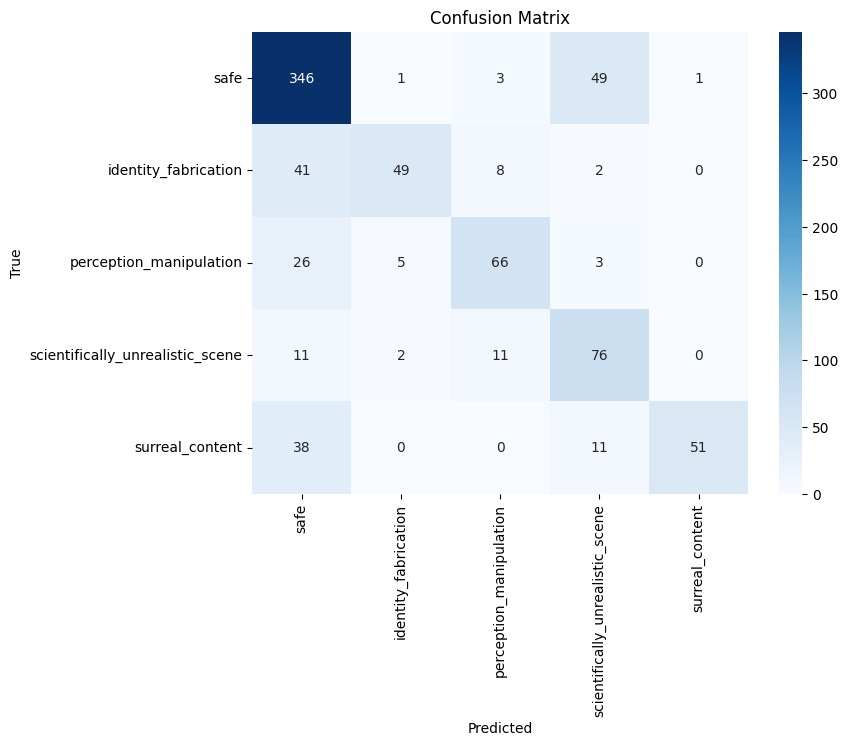

                                  precision    recall  f1-score   support

                            safe       0.75      0.86      0.80       400
            identity_fabrication       0.86      0.49      0.62       100
         perception_manipulation       0.75      0.66      0.70       100
scientifically_unrealistic_scene       0.54      0.76      0.63       100
                 surreal_content       0.98      0.51      0.67       100

                        accuracy                           0.73       800
                       macro avg       0.78      0.66      0.69       800
                    weighted avg       0.77      0.73      0.73       800



In [25]:
# ============================================================
# CELL 24 — CONFUSION MATRIX + CLASSIFICATION REPORT
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

class_names = [
    "safe",
    "identity_fabrication",
    "perception_manipulation",
    "scientifically_unrealistic_scene",
    "surreal_content"
]

# confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()


# classification report
report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names
)

print(report)

## Stage 1 — Binary Classifier

Detect:

SAFE vs MISLEADING

In [26]:
# ============================================================
# CELL 25 — CREATE BINARY LABELS
# ============================================================

train_df["binary_label"] = train_df["category"].apply(
    lambda x: 0 if x == "safe" else 1
)

test_df["binary_label"] = test_df["category"].apply(
    lambda x: 0 if x == "safe" else 1
)

print("Binary label distribution (train):")
print(train_df["binary_label"].value_counts())

Binary label distribution (train):
binary_label
1    800
0    800
Name: count, dtype: int64


In [27]:
# ============================================================
# CELL 26 — BINARY DATASET
# ============================================================

class BinaryMultimodalDataset(Dataset):
    
    def __init__(self, dataframe, frames_root, audio_root):
        
        self.df = dataframe.reset_index(drop=True)
        self.frames_root = frames_root
        self.audio_root = audio_root
        
    def __len__(self):
        return len(self.df)
    
    
    def __getitem__(self, idx):
        
        row = self.df.iloc[idx]
        
        video_id = row["video_id"]
        
        # -----------------------
        # Vision
        # -----------------------
        frames = load_frames(video_id, self.frames_root)
        
        
        # -----------------------
        # Text
        # -----------------------
        transcript = str(row["transcript"])
        ocr = str(row["ocr_text"])
        
        text = transcript + " " + ocr
        
        
        # -----------------------
        # Audio
        # -----------------------
        audio_path = self.audio_root / f"{video_id}.wav"
        
        mfcc = extract_mfcc(audio_path)
        
        audio = torch.tensor(mfcc).unsqueeze(0)
        
        
        # -----------------------
        # Binary Label
        # -----------------------
        label = row["binary_label"]
        
        
        return {
            "frames": frames,
            "text": text,
            "audio": audio,
            "label": label
        }


print("Binary dataset class created.")

Binary dataset class created.


In [28]:
# ============================================================
# CELL 27 — BINARY DATALOADERS
# ============================================================

BATCH_SIZE = 4

binary_train_dataset = BinaryMultimodalDataset(
    train_df,
    TRAIN_FRAMES,
    TRAIN_AUDIO
)

binary_test_dataset = BinaryMultimodalDataset(
    test_df,
    TEST_FRAMES,
    TEST_AUDIO
)

binary_train_loader = DataLoader(
    binary_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

binary_test_loader = DataLoader(
    binary_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Binary train batches:", len(binary_train_loader))
print("Binary test batches:", len(binary_test_loader))

Binary train batches: 400
Binary test batches: 200


In [29]:
# ============================================================
# CELL 28 — STAGE 1 BINARY MODEL
# ============================================================

class BinaryFusionClassifierVTA(nn.Module):
    
    def __init__(self, fusion_dim=1664, num_classes=2, audio_out=128):
        super().__init__()
        
        self.audio_encoder = AudioEncoder(out_dim=audio_out)
        
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim,512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512,num_classes)
        )
    
    
    def forward(self,frames,text,audio):
        
        B = frames.size(0)
        
        # -------------------------
        # Vision
        # -------------------------
        frames = frames.view(-1,3,224,224).to(device)
        
        with torch.no_grad():
            vision_feat = clip_vision_embed(frames)
        
        vision_feat = vision_feat.view(B,16,-1).mean(dim=1)
        
        
        # -------------------------
        # Text
        # -------------------------
        with torch.no_grad():
            text_feat = text_embed(list(text))
        
        
        # -------------------------
        # Audio
        # -------------------------
        audio = audio.to(device)
        
        audio_feat = self.audio_encoder(audio)
        
        
        # -------------------------
        # Fusion
        # -------------------------
        fusion = torch.cat(
            [vision_feat,text_feat,audio_feat],
            dim=1
        )
        
        
        # -------------------------
        # Classification
        # -------------------------
        out = self.classifier(fusion)
        
        return out


binary_model = BinaryFusionClassifierVTA().to(device)

print("Stage-1 binary model created.")

Stage-1 binary model created.


In [30]:
# ============================================================
# CELL 29 — BINARY TRAINING SETUP
# ============================================================

binary_criterion = nn.CrossEntropyLoss()

binary_optimizer = optim.Adam(
    list(binary_model.classifier.parameters()) +
    list(binary_model.audio_encoder.parameters()),
    lr=1e-3
)

binary_scaler = torch.amp.GradScaler("cuda")

trainable_params = sum(p.numel() for p in binary_model.parameters() if p.requires_grad)

print("Binary training setup ready.")
print("Trainable parameters:", trainable_params)

Binary training setup ready.
Trainable parameters: 1008002


In [31]:
# ============================================================
# CELL 30 — BINARY TRAINING FUNCTION
# ============================================================

def binary_train_epoch(model, loader, optimizer, criterion):
    
    model.train()
    
    total_loss = 0
    preds = []
    labels_all = []
    
    for batch in tqdm(loader):
        
        frames = batch["frames"].to(device)
        text = batch["text"]
        audio = batch["audio"].to(device)
        labels = batch["label"].to(device)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast("cuda"):
            
            outputs = model(frames, text, audio)
            
            loss = criterion(outputs, labels)
        
        binary_scaler.scale(loss).backward()
        binary_scaler.step(optimizer)
        binary_scaler.update()
        
        total_loss += loss.item()
        
        pred = outputs.argmax(dim=1).detach().cpu().numpy()
        
        preds.extend(pred)
        labels_all.extend(labels.cpu().numpy())
    
    acc = accuracy_score(labels_all, preds)
    f1 = f1_score(labels_all, preds, average="weighted")
    
    return total_loss/len(loader), acc, f1


print("Binary training function ready.")

Binary training function ready.


In [32]:
# ============================================================
# CELL 31 — BINARY EVALUATION FUNCTION
# ============================================================

def binary_evaluate(model, loader, criterion):
    
    model.eval()
    
    total_loss = 0
    preds = []
    labels_all = []
    
    with torch.no_grad():
        
        for batch in tqdm(loader):
            
            frames = batch["frames"].to(device)
            text = batch["text"]
            audio = batch["audio"].to(device)
            labels = batch["label"].to(device)
            
            outputs = model(frames, text, audio)
            
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            
            pred = outputs.argmax(dim=1).cpu().numpy()
            
            preds.extend(pred)
            labels_all.extend(labels.cpu().numpy())
    
    acc = accuracy_score(labels_all, preds)
    f1 = f1_score(labels_all, preds, average="weighted")
    
    return total_loss/len(loader), acc, f1


print("Binary evaluation function ready.")

Binary evaluation function ready.


In [33]:
# ============================================================
# CELL 32 — STAGE 1 TRAINING LOOP (SAFE vs MISLEADING)
# ============================================================

BINARY_EPOCHS = 5

for epoch in range(BINARY_EPOCHS):

    print(f"\nStage-1 Epoch {epoch+1}/{BINARY_EPOCHS}")

    train_loss, train_acc, train_f1 = binary_train_epoch(
        binary_model,
        binary_train_loader,
        binary_optimizer,
        binary_criterion
    )

    test_loss, test_acc, test_f1 = binary_evaluate(
        binary_model,
        binary_test_loader,
        binary_criterion
    )

    print("\nTrain Loss:", round(train_loss,4))
    print("Train Accuracy:", round(train_acc,4))
    print("Train F1:", round(train_f1,4))

    print("\nTest Loss:", round(test_loss,4))
    print("Test Accuracy:", round(test_acc,4))
    print("Test F1:", round(test_f1,4))


Stage-1 Epoch 1/5


100%|██████████| 200/200 [01:09<00:00,  2.87it/s]



Train Loss: 0.2575
Train Accuracy: 0.8919
Train F1: 0.8919

Test Loss: 0.4214
Test Accuracy: 0.8287
Test F1: 0.8287

Stage-1 Epoch 2/5


100%|██████████| 200/200 [01:09<00:00,  2.90it/s]



Train Loss: 0.1516
Train Accuracy: 0.9419
Train F1: 0.9419

Test Loss: 0.6174
Test Accuracy: 0.8125
Test F1: 0.8114

Stage-1 Epoch 3/5


...


Train Loss: 0.1179
Train Accuracy: 0.9537
Train F1: 0.9537

Test Loss: 0.5379
Test Accuracy: 0.8275
Test F1: 0.8269

Stage-1 Epoch 4/5


100%|██████████| 200/200 [01:08<00:00,  2.94it/s]



Train Loss: 0.0801
Train Accuracy: 0.9731
Train F1: 0.9731

Test Loss: 0.6247
Test Accuracy: 0.8125
Test F1: 0.8124

Stage-1 Epoch 5/5


100%|██████████| 200/200 [01:09<00:00,  2.88it/s]


Train Loss: 0.0631
Train Accuracy: 0.9781
Train F1: 0.9781

Test Loss: 0.9075
Test Accuracy: 0.7975
Test F1: 0.796


In [34]:
torch.save(binary_model.state_dict(), "stage1_binary_model.pth")

print("Stage-1 model saved.")

Stage-1 model saved.


## Stage-2: Misleading Type Classification.

Stage-2 will only see videos where:

category = misleading

So it will classify between:

identity_fabrication
perception_manipulation
scientifically_unrealistic_scene
surreal_content

In [35]:
# ============================================================
# CELL 33 — CREATE MISLEADING SUBSET
# ============================================================

mis_train_df = train_df[train_df["category"] == "misleading"].reset_index(drop=True)
mis_test_df  = test_df[test_df["category"] == "misleading"].reset_index(drop=True)

print("Misleading train samples:", len(mis_train_df))
print("Misleading test samples:", len(mis_test_df))

print("\nClass distribution (train):")
print(mis_train_df["subcategory"].value_counts())

Misleading train samples: 800
Misleading test samples: 400

Class distribution (train):
subcategory
identity_fabrication                200
perception_manipulation             200
scientifically_unrealistic_scene    200
surreal_content                     200
Name: count, dtype: int64


In [36]:
# ============================================================
# CELL 34 — CREATE STAGE-2 LABELS
# ============================================================

mis_label_map = {
    "identity_fabrication": 0,
    "perception_manipulation": 1,
    "scientifically_unrealistic_scene": 2,
    "surreal_content": 3
}

mis_train_df["mis_label"] = mis_train_df["subcategory"].map(mis_label_map)
mis_test_df["mis_label"]  = mis_test_df["subcategory"].map(mis_label_map)

print("Stage-2 label distribution (train):")
print(mis_train_df["mis_label"].value_counts())

Stage-2 label distribution (train):
mis_label
0    200
1    200
2    200
3    200
Name: count, dtype: int64


In [37]:
# ============================================================
# CELL 35 — STAGE-2 DATASET (MISLEADING TYPES)
# ============================================================

class MisleadingDataset(Dataset):
    
    def __init__(self, dataframe, frames_root, audio_root):
        
        self.df = dataframe.reset_index(drop=True)
        self.frames_root = frames_root
        self.audio_root = audio_root
        
    def __len__(self):
        return len(self.df)
    
    
    def __getitem__(self, idx):
        
        row = self.df.iloc[idx]
        video_id = row["video_id"]
        
        # -----------------------
        # Vision
        # -----------------------
        frames = load_frames(video_id, self.frames_root)
        
        
        # -----------------------
        # Text
        # -----------------------
        transcript = str(row["transcript"])
        ocr = str(row["ocr_text"])
        text = transcript + " " + ocr
        
        
        # -----------------------
        # Audio
        # -----------------------
        audio_path = self.audio_root / f"{video_id}.wav"
        mfcc = extract_mfcc(audio_path)
        audio = torch.tensor(mfcc).unsqueeze(0)
        
        
        # -----------------------
        # Label
        # -----------------------
        label = row["mis_label"]
        
        
        return {
            "frames": frames,
            "text": text,
            "audio": audio,
            "label": label
        }


print("Stage-2 dataset class created.")

Stage-2 dataset class created.


In [38]:
# ============================================================
# CELL 36 — STAGE-2 DATALOADERS
# ============================================================

BATCH_SIZE = 4

mis_train_dataset = MisleadingDataset(
    mis_train_df,
    TRAIN_FRAMES,
    TRAIN_AUDIO
)

mis_test_dataset = MisleadingDataset(
    mis_test_df,
    TEST_FRAMES,
    TEST_AUDIO
)

mis_train_loader = DataLoader(
    mis_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

mis_test_loader = DataLoader(
    mis_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Stage-2 train batches:", len(mis_train_loader))
print("Stage-2 test batches:", len(mis_test_loader))

Stage-2 train batches: 200
Stage-2 test batches: 100


In [39]:
# ============================================================
# CELL 37 — STAGE-2 MODEL (MISLEADING TYPES)
# ============================================================

class Stage2FusionClassifier(nn.Module):
    
    def __init__(self, fusion_dim=1664, num_classes=4, audio_out=128):
        super().__init__()
        
        self.audio_encoder = AudioEncoder(out_dim=audio_out)
        
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim,512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512,num_classes)
        )
    
    
    def forward(self,frames,text,audio):
        
        B = frames.size(0)
        
        # Vision
        frames = frames.view(-1,3,224,224).to(device)
        with torch.no_grad():
            vision_feat = clip_vision_embed(frames)
        vision_feat = vision_feat.view(B,16,-1).mean(dim=1)
        
        # Text
        with torch.no_grad():
            text_feat = text_embed(list(text))
        
        # Audio
        audio = audio.to(device)
        audio_feat = self.audio_encoder(audio)
        
        # Fusion
        fusion = torch.cat(
            [vision_feat,text_feat,audio_feat],
            dim=1
        )
        
        # Classification
        out = self.classifier(fusion)
        
        return out


stage2_model = Stage2FusionClassifier().to(device)

print("Stage-2 model created.")

Stage-2 model created.


In [40]:
# ============================================================
# CELL 38 — STAGE-2 TRAINING SETUP
# ============================================================

stage2_criterion = nn.CrossEntropyLoss()

stage2_optimizer = optim.Adam(
    list(stage2_model.classifier.parameters()) +
    list(stage2_model.audio_encoder.parameters()),
    lr=1e-3
)

stage2_scaler = torch.amp.GradScaler("cuda")

trainable_params = sum(p.numel() for p in stage2_model.parameters() if p.requires_grad)

print("Stage-2 training setup ready.")
print("Trainable parameters:", trainable_params)

Stage-2 training setup ready.
Trainable parameters: 1009028


In [41]:
# ============================================================
# CELL 39 — STAGE-2 TRAINING FUNCTION
# ============================================================

def stage2_train_epoch(model, loader, optimizer, criterion):

    model.train()

    total_loss = 0
    preds = []
    labels_all = []

    for batch in tqdm(loader):

        frames = batch["frames"].to(device)
        text = batch["text"]
        audio = batch["audio"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):

            outputs = model(frames, text, audio)

            loss = criterion(outputs, labels)

        stage2_scaler.scale(loss).backward()
        stage2_scaler.step(optimizer)
        stage2_scaler.update()

        total_loss += loss.item()

        pred = outputs.argmax(dim=1).detach().cpu().numpy()

        preds.extend(pred)
        labels_all.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_all, preds)
    f1 = f1_score(labels_all, preds, average="weighted")

    return total_loss/len(loader), acc, f1


print("Stage-2 training function ready.")

Stage-2 training function ready.


In [42]:
# ============================================================
# CELL 40 — STAGE-2 EVALUATION FUNCTION
# ============================================================

def stage2_evaluate(model, loader, criterion):

    model.eval()

    total_loss = 0
    preds = []
    labels_all = []

    with torch.no_grad():

        for batch in tqdm(loader):

            frames = batch["frames"].to(device)
            text = batch["text"]
            audio = batch["audio"].to(device)
            labels = batch["label"].to(device)

            outputs = model(frames, text, audio)

            loss = criterion(outputs, labels)

            total_loss += loss.item()

            pred = outputs.argmax(dim=1).cpu().numpy()

            preds.extend(pred)
            labels_all.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_all, preds)
    f1 = f1_score(labels_all, preds, average="weighted")
    macro_f1 = f1_score(labels_all, preds, average="macro")

    return total_loss/len(loader), acc, f1, macro_f1


print("Stage-2 evaluation function ready.")

Stage-2 evaluation function ready.


In [43]:
# ============================================================
# CELL 41 — STAGE-2 TRAINING LOOP
# ============================================================

STAGE2_EPOCHS = 5

for epoch in range(STAGE2_EPOCHS):

    print(f"\nStage-2 Epoch {epoch+1}/{STAGE2_EPOCHS}")

    train_loss, train_acc, train_f1 = stage2_train_epoch(
        stage2_model,
        mis_train_loader,
        stage2_optimizer,
        stage2_criterion
    )

    test_loss, test_acc, test_f1, test_macro_f1 = stage2_evaluate(
        stage2_model,
        mis_test_loader,
        stage2_criterion
    )

    print("\nTrain Loss:", round(train_loss,4))
    print("Train Accuracy:", round(train_acc,4))
    print("Train F1:", round(train_f1,4))

    print("\nTest Loss:", round(test_loss,4))
    print("Test Accuracy:", round(test_acc,4))
    print("Test Weighted F1:", round(test_f1,4))
    print("Test Macro F1:", round(test_macro_f1,4))


Stage-2 Epoch 1/5


100%|██████████| 100/100 [00:34<00:00,  2.90it/s]



Train Loss: 0.5112
Train Accuracy: 0.815
Train F1: 0.814

Test Loss: 0.6222
Test Accuracy: 0.7575
Test Weighted F1: 0.7607
Test Macro F1: 0.7607

Stage-2 Epoch 2/5


100%|██████████| 100/100 [00:34<00:00,  2.94it/s]



Train Loss: 0.2054
Train Accuracy: 0.9287
Train F1: 0.9284

Test Loss: 0.8292
Test Accuracy: 0.7175
Test Weighted F1: 0.7137
Test Macro F1: 0.7137

Stage-2 Epoch 3/5


...


Train Loss: 0.1178
Train Accuracy: 0.9625
Train F1: 0.9625

Test Loss: 0.9268
Test Accuracy: 0.705
Test Weighted F1: 0.6982
Test Macro F1: 0.6982

Stage-2 Epoch 4/5


100%|██████████| 100/100 [00:34<00:00,  2.88it/s]



Train Loss: 0.0822
Train Accuracy: 0.9725
Train F1: 0.9725

Test Loss: 1.1541
Test Accuracy: 0.69
Test Weighted F1: 0.6888
Test Macro F1: 0.6888

Stage-2 Epoch 5/5


100%|██████████| 100/100 [00:34<00:00,  2.88it/s]


Train Loss: 0.0768
Train Accuracy: 0.9688
Train F1: 0.9687

Test Loss: 1.244
Test Accuracy: 0.7
Test Weighted F1: 0.7
Test Macro F1: 0.7


In [44]:
torch.save(stage2_model.state_dict(), "stage2_misleading_model.pth")

print("Both models saved.")

Both models saved.


In [45]:
@torch.no_grad()
def hierarchical_predict(frames16, text, audio_mfcc):

    binary_model.eval()
    stage2_model.eval()

    # Frames
    frames = frames16.unsqueeze(0).to(device)   # (1,16,3,224,224)

    # Audio FIX
    audio = audio_mfcc.unsqueeze(0).unsqueeze(0).to(device)  # (1,1,40,160)

    # ---------- Stage 1 ----------
    logits1 = binary_model(frames, [text], audio)

    probs1 = torch.softmax(logits1, dim=1)[0].cpu().numpy()
    pred1 = int(np.argmax(probs1))

    if pred1 == 0:
        return {
            "label": "safe",
            "confidence": float(probs1[0]),
            "stage1_probs": probs1
        }

    # ---------- Stage 2 ----------
    logits2 = stage2_model(frames, [text], audio)

    probs2 = torch.softmax(logits2, dim=1)[0].cpu().numpy()
    pred2 = int(np.argmax(probs2))

    mis_map = {
        0:"identity_fabrication",
        1:"perception_manipulation",
        2:"scientifically_unrealistic_scene",
        3:"surreal_content"
    }

    return {
        "label": mis_map[pred2],
        "confidence": float(probs2[pred2]),
        "stage1_probs": probs1,
        "stage2_probs": probs2
    }

In [46]:
# ============================================================
# CELL 43 — PREDICT VIDEO BY ID
# ============================================================

def predict_video(video_id, split="test"):

    df = test_df if split == "test" else train_df
    row = df[df["video_id"] == video_id].iloc[0]

    transcript = str(row["transcript"])
    ocr = str(row["ocr_text"])

    text = transcript + " " + ocr

    frames = load_frames(video_id, TEST_FRAMES if split=="test" else TRAIN_FRAMES)

    audio_path = (TEST_AUDIO if split=="test" else TRAIN_AUDIO) / f"{video_id}.wav"
    mfcc = extract_mfcc(audio_path)

    result = hierarchical_predict(frames, text, torch.tensor(mfcc))

    print("\nPrediction:", result["label"])
    print("Confidence:", result["confidence"])

    return result

In [47]:
# ============================================================
# CELL 44 — FRAME IMPORTANCE
# ============================================================

def frame_importance(video_id, split="test"):

    df = test_df if split == "test" else train_df
    row = df[df["video_id"] == video_id].iloc[0]

    text = str(row["transcript"]) + " " + str(row["ocr_text"])

    frames = load_frames(video_id, TEST_FRAMES if split=="test" else TRAIN_FRAMES)

    audio_path = (TEST_AUDIO if split=="test" else TRAIN_AUDIO) / f"{video_id}.wav"
    mfcc = extract_mfcc(audio_path)
    audio = torch.tensor(mfcc)

    base = hierarchical_predict(frames, text, audio)["confidence"]

    scores = []

    for i in range(16):

        abl = frames.clone()
        abl[i] = 0

        prob = hierarchical_predict(abl, text, audio)["confidence"]

        scores.append(max(0, base - prob))

    scores = np.array(scores)

    plt.figure(figsize=(12,4))
    plt.bar(range(16), scores)
    plt.title("Frame importance")
    plt.show()

    return scores

In [48]:
# ============================================================
# CELL 45 — TEXT SOURCE INFLUENCE
# ============================================================

def text_influence(video_id, split="test"):

    df = test_df if split == "test" else train_df
    row = df[df["video_id"] == video_id].iloc[0]

    transcript = str(row["transcript"])
    ocr = str(row["ocr_text"])

    frames = load_frames(video_id, TEST_FRAMES if split=="test" else TRAIN_FRAMES)

    audio_path = (TEST_AUDIO if split=="test" else TRAIN_AUDIO) / f"{video_id}.wav"
    mfcc = extract_mfcc(audio_path)
    audio = torch.tensor(mfcc)

    p_transcript = hierarchical_predict(frames, transcript, audio)
    p_ocr = hierarchical_predict(frames, ocr, audio)

    print("Transcript only confidence:", p_transcript["confidence"])
    print("OCR only confidence:", p_ocr["confidence"])

In [49]:
# ============================================================
# CELL 46 — AUDIO CHUNK IMPORTANCE
# ============================================================

def audio_importance(video_id, split="test"):

    df = test_df if split == "test" else train_df
    row = df[df["video_id"] == video_id].iloc[0]

    text = str(row["transcript"]) + " " + str(row["ocr_text"])

    frames = load_frames(video_id, TEST_FRAMES if split=="test" else TRAIN_FRAMES)

    audio_path = (TEST_AUDIO if split=="test" else TRAIN_AUDIO) / f"{video_id}.wav"
    mfcc = extract_mfcc(audio_path)

    base = hierarchical_predict(frames, text, torch.tensor(mfcc))["confidence"]

    mfcc = torch.tensor(mfcc)

    drops = []

    for i in range(5):

        a = mfcc.clone()

        start = i*32
        end = (i+1)*32

        a[:,start:end] = 0

        prob = hierarchical_predict(frames, text, a)["confidence"]

        drops.append(max(0, base - prob))

    plt.bar(range(5), drops)
    plt.title("Audio chunk importance")
    plt.show()

    return drops

In [50]:
# ============================================================
# CELL 47 — FULL XAI REPORT
# ============================================================

def run_xai(video_id, split="test"):

    print("\n==================== XAI REPORT ====================")

    result = predict_video(video_id, split)

    print("\n--- Frame importance ---")
    frame_importance(video_id, split)

    print("\n--- Text influence ---")
    text_influence(video_id, split)

    print("\n--- Audio influence ---")
    audio_importance(video_id, split)

    print("\nExplanation:")

    if result["label"] == "safe":
        print("The video is safe because no misleading multimodal signals are detected.")

    elif result["label"] == "identity_fabrication":
        print("The video likely fabricates identity or authority claims.")

    elif result["label"] == "perception_manipulation":
        print("The video manipulates perception through emotional framing.")

    elif result["label"] == "scientifically_unrealistic_scene":
        print("The video shows events inconsistent with real-world science.")

    elif result["label"] == "surreal_content":
        print("The video contains unrealistic or surreal visual content.")

In [51]:
# ============================================================
# RELOAD TRAINED MODELS
# ============================================================

binary_model.load_state_dict(torch.load("stage1_binary_model.pth", map_location=device))
stage2_model.load_state_dict(torch.load("stage2_misleading_model.pth", map_location=device))

binary_model.eval()
stage2_model.eval()

print("Trained models loaded successfully.")

Trained models loaded successfully.



==================== XAI REPORT ====================

Prediction: perception_manipulation
Confidence: 0.9994449019432068

--- Frame importance ---


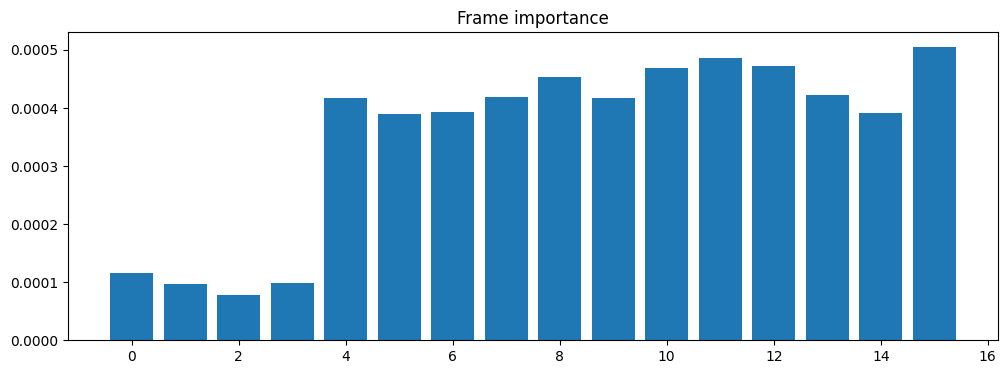


--- Text influence ---
Transcript only confidence: 0.7777726650238037
OCR only confidence: 0.9994024038314819

--- Audio influence ---


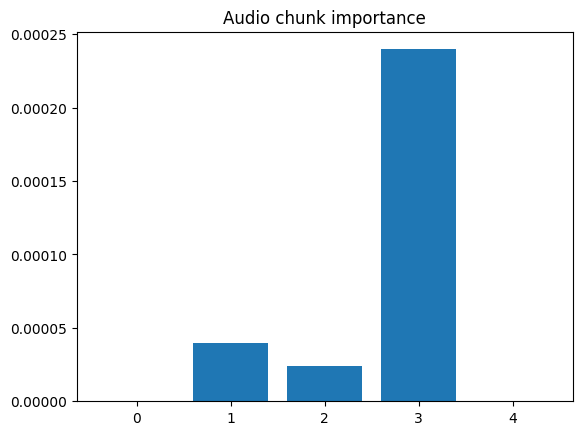


Explanation:
The video manipulates perception through emotional framing.


In [52]:
run_xai("TEST_PM_053", split="test")


==================== XAI REPORT ====================

Prediction: surreal_content
Confidence: 0.8379225134849548

--- Frame importance ---


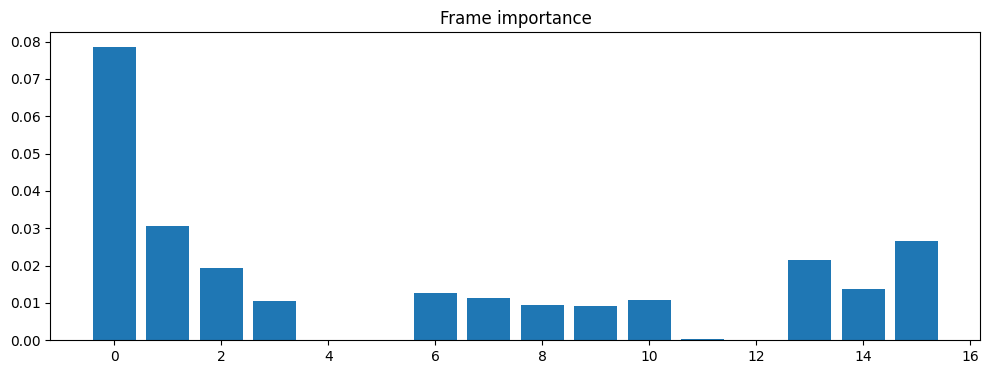


--- Text influence ---
Transcript only confidence: 0.8690965175628662
OCR only confidence: 0.8543364405632019

--- Audio influence ---


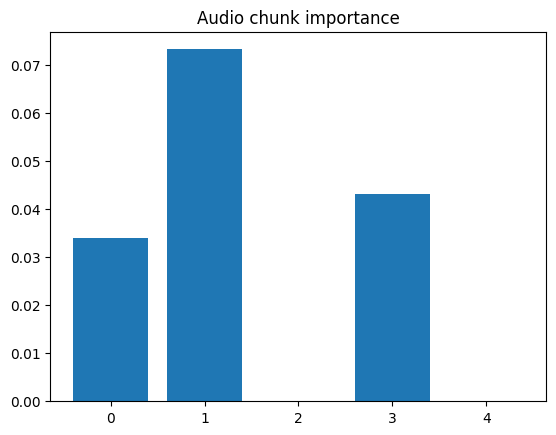


Explanation:
The video contains unrealistic or surreal visual content.


In [53]:
run_xai("TEST_SC_023", split="test")


==================== XAI REPORT ====================

Prediction: identity_fabrication
Confidence: 0.9905447959899902

--- Frame importance ---


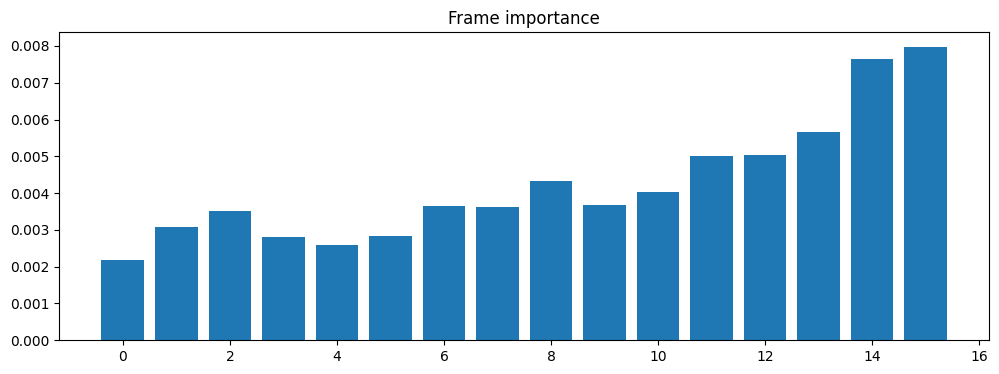


--- Text influence ---
Transcript only confidence: 0.9945610165596008
OCR only confidence: 0.9757831692695618

--- Audio influence ---


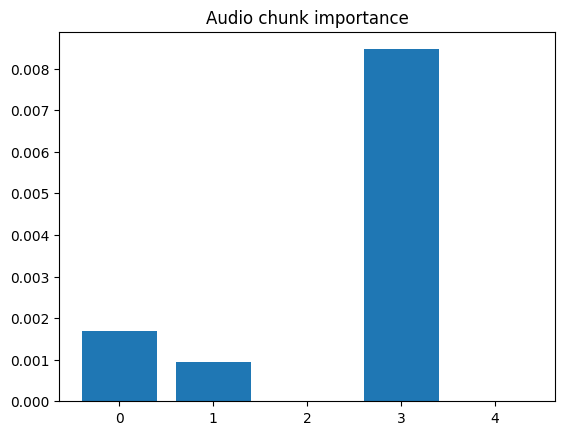


Explanation:
The video likely fabricates identity or authority claims.


In [54]:
run_xai("TEST_IF_016", split="test")


==================== XAI REPORT ====================

Prediction: scientifically_unrealistic_scene
Confidence: 0.9999903440475464

--- Frame importance ---


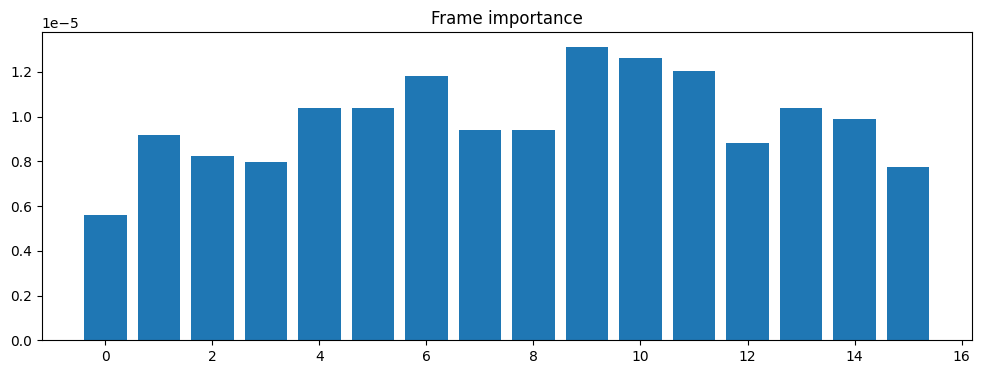


--- Text influence ---
Transcript only confidence: 0.9999877214431763
OCR only confidence: 0.9999886751174927

--- Audio influence ---


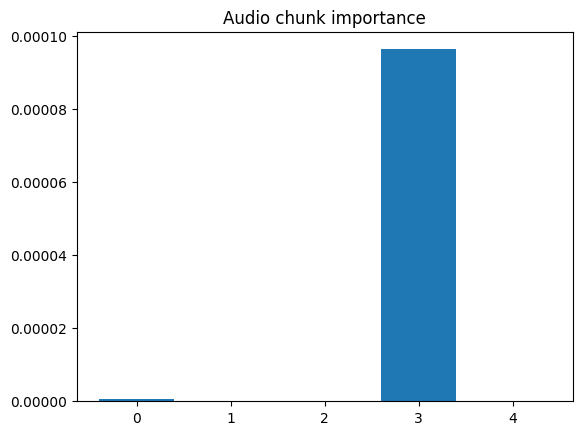


Explanation:
The video shows events inconsistent with real-world science.


In [55]:
run_xai("TEST_SUS_077", split="test")


==================== XAI REPORT ====================

Prediction: safe
Confidence: 0.9986091256141663

--- Frame importance ---


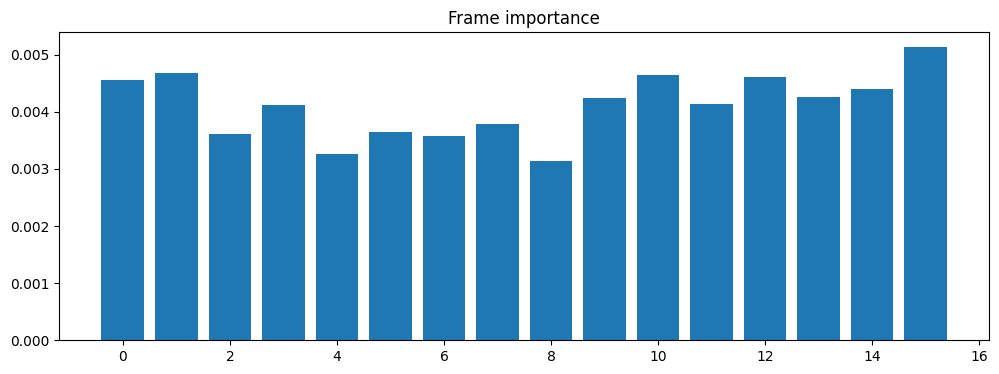


--- Text influence ---
Transcript only confidence: 0.9996933937072754
OCR only confidence: 0.9989417195320129

--- Audio influence ---


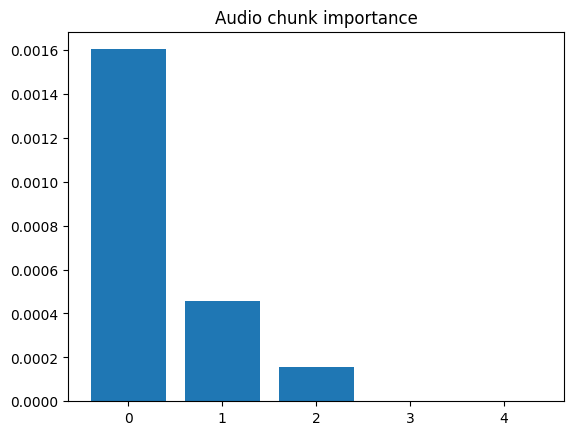


Explanation:
The video is safe because no misleading multimodal signals are detected.


In [56]:
run_xai("TEST_SAFE_123", split="test")

# Video Check

if any vide fails to load in run XAi

In [57]:
video_id = "TEST_PM_023"

row = test_df[test_df["video_id"] == video_id].iloc[0]

print("Transcript length:", len(str(row["transcript"])))
print("OCR length:", len(str(row["ocr_text"])))

frame_dir = TEST_FRAMES / video_id
print("Frame folder exists:", frame_dir.exists())

audio_path = TEST_AUDIO / f"{video_id}.wav"
print("Audio exists:", audio_path.exists())

Transcript length: 23
OCR length: 22
Frame folder exists: True
Audio exists: True
